## EDA proyectos de ley sobre salud

Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 
pd.options.display.float_format = '{:.2f}'.format
sns.set_theme(context="talk")

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale

#locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos


In [4]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [5]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    base_texto_df = pickle.load(file)
# Seleccionando IL de Salud
df = base_texto_df[base_texto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",df.shape)
df = df[~df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (2848, 12)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 12)


In [6]:
df = df[~(df['Título normalizado']==" ")]
print("Conj. de datos de proyecto_SALUD sin título vacio:",df.shape)

Conj. de datos de proyecto_SALUD sin título vacio: (2848, 12)


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cant_token,2848.00,19.25,10.00,2.00,12.00,18.00,24.00,125.00
Cant_token_procesados,2848.00,19.09,10.00,2.00,12.00,17.00,24.00,128.00
Cant_token_normalizado,2848.00,9.77,4.66,1.00,6.00,9.00,12.00,50.00
Proyecto_SALUD,2848.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Periodo,2848.00,134.39,4.09,127.00,131.00,135.00,138.00,141.00
Año,2848.00,2016.42,4.11,2009.00,2013.00,2017.00,2020.00,2024.00


A partir de la base de datos integrada de 92.535 proyectos correspondientes a los períodos parlamentarios 127 a 141 (años 2009–2024), se recopilaron los títulos de los proyectos de
ley con el fin de construir el corpus analizado. Para el preprocesamiento específico del subcorpus de salud, se consideraron inicialmente los 33.097 títulos de proyectos de ley
disponibles con el fin de caracterizar el vocabulario legislativo - jurídico. 
El preprocesamiento redujo de manera sustancial la dimensionalidad y variabilidad del vocabulario, así como en la longitud media de los títulos en ambos corpus. Por ejemplo,
en los proyectos de ley sobre salud, la longitud promedio disminuyó de 19,25 a 9,77 tokens tras la limpieza, mientras que el número de tokens únicos se redujo en un 50,9 %. Estos
cambios reflejan la eliminación de ruido, la normalización y pérdida de contexto. Lo cual afecta la disponibilidad de datos y calidad de word embeddings.

In [8]:
from pprint import pprint
#from gensim import corpora
from collections import defaultdict
from collections import Counter

corpus_norm = list(df['Título normalizado'])
# Tokenizamos
documents_tok = [word.split() for word in corpus_norm]

# Creamos el diccionario (vocabulario)
frequency = defaultdict(int)
for doc in documents_tok:
    for token in doc:
        frequency[token] += 1

# Exploramos todas las palabras para limpiar mejor
#counter = Counter(frequency)
frecuencia_df = pd.DataFrame.from_records(list(frequency.items()), columns = ['token','frecuencia'])
display(frecuencia_df.describe())

,frecuencia
count,3221.00
mean,8.63
std,31.12
min,1.00
25%,1.00
50%,2.00
75%,6.00
max,836.00


#### Figura 4.1

Focalizando en el corpus de proyectos de ley sobre salud con procesamiento, la distribución de frecuencias evidencia un patrón típico de long-tail, con una mediana de 2 ocurrencias
por término, indicando que la mayoría de las palabras aparecen escasas veces en el corpus.

In [9]:
RED_HEALTH   = "#7A2E2E"
GREEN_HEALTH = "#8FBFA8"

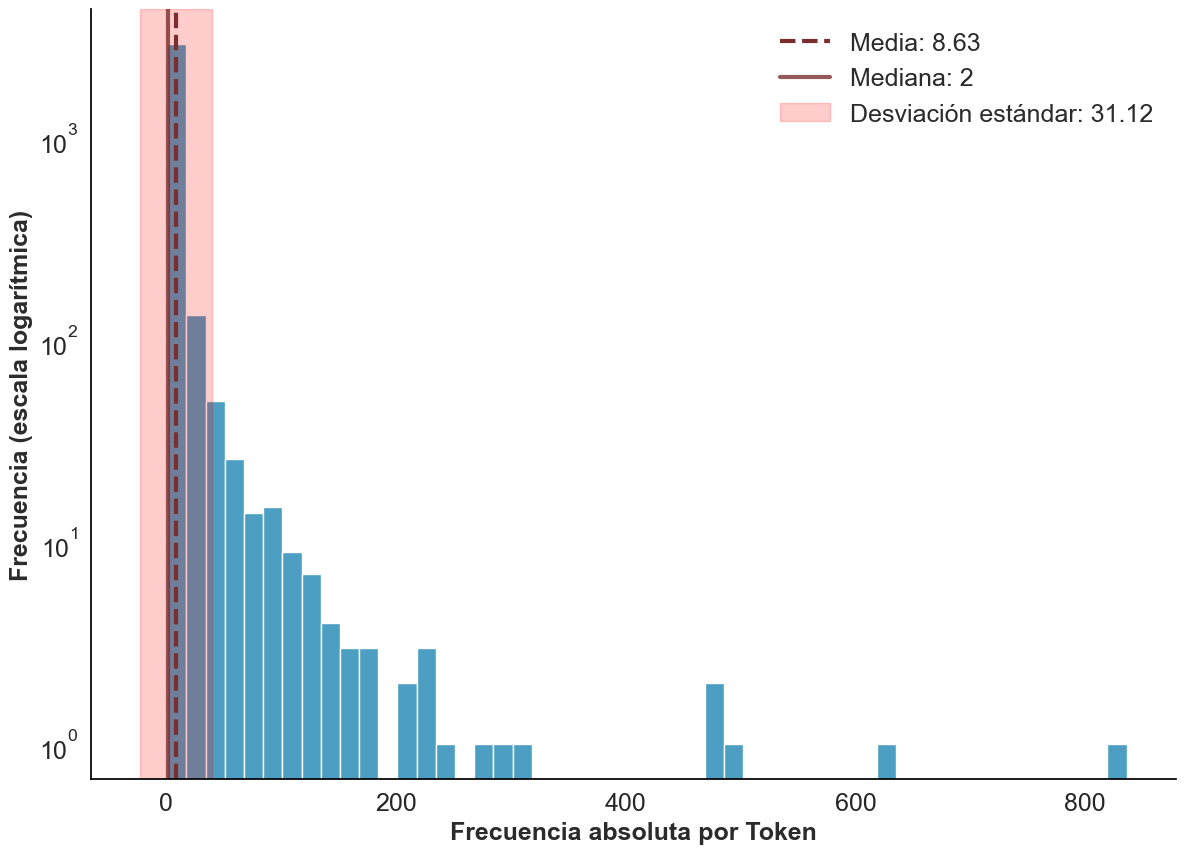

=== ESTADÍSTICAS DESCRIPTIVAS ===
Media: 8.63
Mediana: 2.00
Desviación estándar: 31.12
Asimetría (Media - Mediana): 6.63
Coeficiente de variación: 360.5%


In [10]:
# En el eje Y (frecuencias)
tokens = frecuencia_df['frecuencia']
plt.figure(figsize=(14, 10))

# Histograma para proyectos de salud
ax= sns.histplot(
    tokens,
    bins=50,
    color=HEALTH_CYAN,
    alpha=0.7
    
)


# Calcular estadísticas
media = np.mean(tokens)
mediana = np.median(tokens)
std = np.std(tokens)

# Añadir líneas verticales
plt.axvline(x=media, color=RED_HEALTH, linestyle='--', linewidth=3, 
            label=f"Media: {locale.format_string('%.2f', media)}")
plt.axvline(x=mediana, color=RED_HEALTH, linestyle='-', linewidth=3,     alpha=0.8,
            label=f"Mediana: {locale.format_string('%.0f', mediana)}")

# Añadir anotaciones de texto
#plt.text(media, plt.ylim()[1]*0.9, f'Media: {media:.2f}', 
#         color='red', fontsize=11, fontweight='bold', ha='center')
#plt.text(mediana, plt.ylim()[1]*0.8, f'Mediana: {mediana:.2f}', 
#         color='green', fontsize=11, fontweight='bold', ha='center')

# Añadir área de desviación estándar (opcional)


plt.axvspan(media-std, media+std, alpha=0.2, color='red', label=f'Desviación estándar: {std:.2f}') #locale.format_string('%.2f', std)
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)


plt.yscale('log')
plt.xlabel("Frecuencia absoluta por Token", fontsize=18, fontweight='bold')
plt.ylabel("Frecuencia (escala logarítmica)", fontsize=18, fontweight='bold')
#plt.title("Distribución de Frecuencias léxicas en el Corpus de Proyecto de Ley sobre Salud - con procesamiento \n(escala logarítmica)", 
#          fontsize=14, fontweight='bold', pad=20)


# Escala logarítmica en Y para visualizar la cola larga
plt.yscale("log")
legend = plt.legend(
    fontsize=18,      # tamaño del texto
    frameon=False     # quita el borde
)
# Quitar completamente el borde y fondo
frame = legend.get_frame()
frame.set_linewidth(0)
frame.set_edgecolor("none")
frame.set_facecolor("none")

ax.grid(False)

# Ocultar bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mantener solo los ejes izquierdo e inferior en negro
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

plt.savefig(BASE_DIR + "imagenes/HistLogY_frecuenciaSALUD.png",
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# Estadísticas adicionales
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {std:.2f}")
print(f"Asimetría (Media - Mediana): {media-mediana:.2f}")
print(f"Coeficiente de variación: {(std/media)*100:.1f}%")

#### Figura 4.2

El léxico predominante refleja la especialización del dominio legislativo-sanitario, sien-
do los términos más frecuentes, extremos: ’nacional’ (836), ’creacion’ (628), ’programa’
(488), ’régimen’ (485) y ’salud’ (483)

In [11]:
HEALTH_ORANGE = '#F57C00'
HEALTH_BLUE = '#455A64'

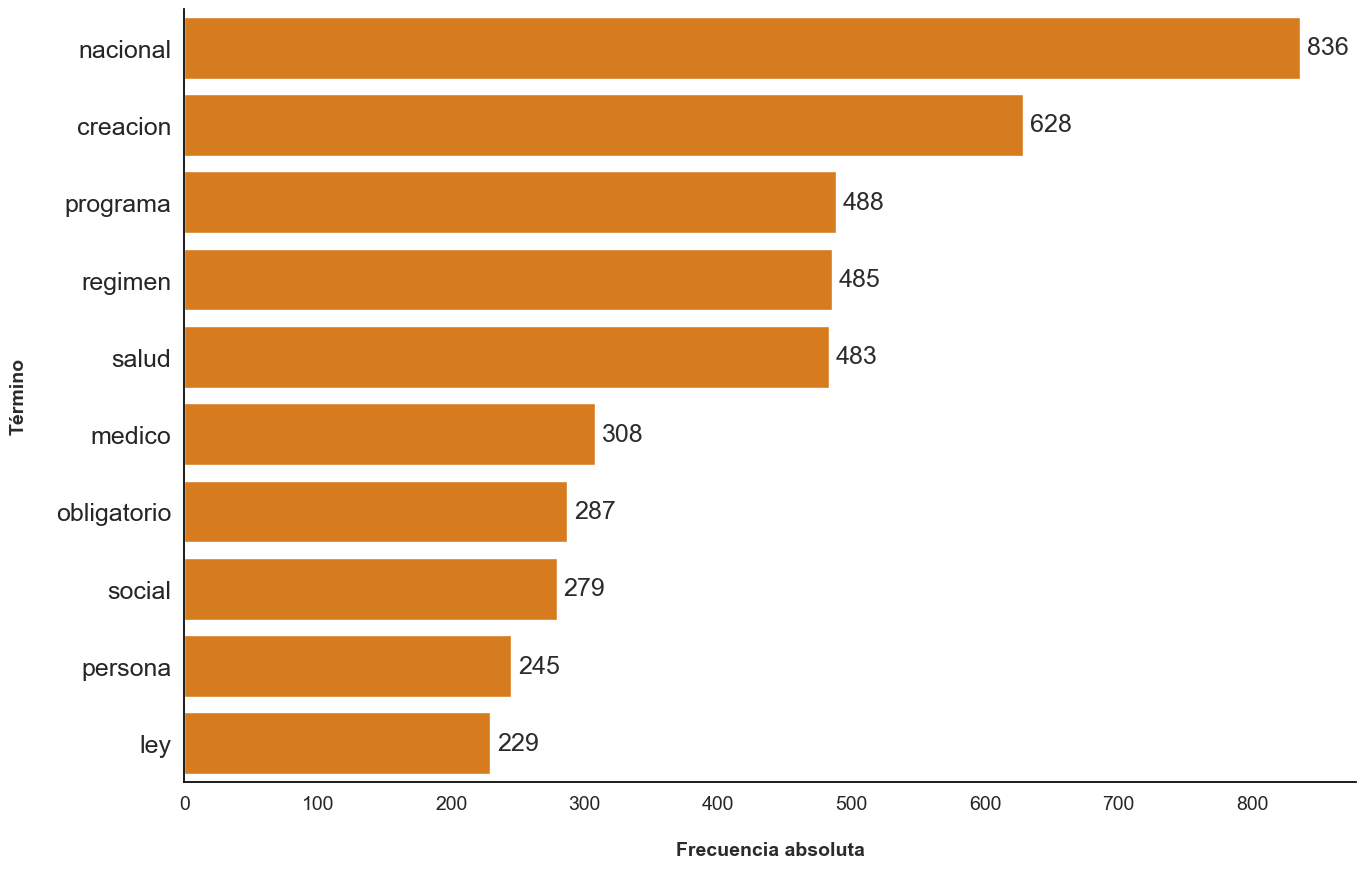

In [12]:
plt.figure(figsize=(14,10))
ax = sns.barplot(data=frecuencia_df.sort_values('frecuencia', ascending=False).head(10), x='frecuencia', y='token', color=HEALTH_ORANGE)
#plt.title("Top 10 Términos más frecuentes en Corpus de Proyecto de Ley sobre Salud - con procesamiento",fontsize=14, fontweight='bold', pad=20)

# Agregar etiquetas con valores
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=5,
        fontsize=18
    )
    
plt.xlabel("Frecuencia absoluta", fontsize=14, 
              fontweight='bold', 
              labelpad=20)
plt.ylabel("Término", fontsize=14, 
              fontweight='bold', 
              labelpad=20)

ax.tick_params(axis='y', labelsize=18)  # Ocultar labels del x-axis superior
ax.tick_params(axis='x', labelsize=14)

ax.grid(False)

# Ocultar bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mantener solo los ejes izquierdo e inferior en negro
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)


plt.savefig(BASE_DIR+'imagenes/top10_masFrecuentesSalud.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


#### Figura 4.3

El análisis temporal de la longitud media de los títulos de los proyectos de ley de salud, considerando las versiones con y sin preprocesamiento, revela patrones diferenciados en
la evolución del discurso legislativo. Tal como se observa en la Figura 4.3, el preprocesamiento genera una homogeneización sustancial de la longitud de los títulos entre períodos
parlamentarios, lo que modifica la detección de tendencias temporales presentes en el texto original.

In [13]:
Temp = pd.pivot_table(df, values=['Cant_token','Cant_token_normalizado'], index=['Periodo'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp['Periodo'] = Temp['Periodo'].astype(int)
Temp['Cant_token'] = Temp['Cant_token'].astype(int)
Temp['Cant_token_normalizado'] = Temp['Cant_token_normalizado'].astype(int)
Temp


,Periodo,Cant_token,Cant_token_normalizado
0,127,19,10
1,128,18,9
2,129,19,10
3,130,17,8
4,131,17,9
5,132,18,9
6,133,19,10
7,134,16,8
8,135,18,9
9,136,18,9


In [14]:
# Calcular diferencia absoluta y porcentual
sin_procesamiento = Temp['Cant_token'] #[19,18,19,17,17,18,19,16,18,18,18,18,17,16,15]
con_procesamiento = Temp['Cant_token_normalizado']  #[10,9,10,8,9,9,10,8,9,9,9,9,9,8,9]
periodos = Temp['Periodo'] 

reduccion_absoluta = [sin - con for sin, con in zip(sin_procesamiento, con_procesamiento)]
reduccion_porcentual = [(sin - con)/sin * 100 for sin, con in zip(sin_procesamiento, con_procesamiento)]

print(f"Reducción absoluta promedio: {np.mean(reduccion_absoluta):.1f} tokens")
print(f"Reducción porcentual promedio: {np.mean(reduccion_porcentual):.1f}%")

Reducción absoluta promedio: 8.5 tokens
Reducción porcentual promedio: 48.6%


In [15]:
# Análisis de Variabilidad
# Calcular coeficiente de variación
cv_sin = np.std(sin_procesamiento) / np.mean(sin_procesamiento) * 100
cv_con = np.std(con_procesamiento) / np.mean(con_procesamiento) * 100

print(f"Variabilidad SIN procesamiento: {cv_sin:.1f}%")
print(f"Variabilidad CON procesamiento: {cv_con:.1f}%")

Variabilidad SIN procesamiento: 6.5%
Variabilidad CON procesamiento: 7.0%


In [16]:
# 2. % Variación periodo a periodo (RECOMENDADO)
def calcular_variacion_porcentual(datos):
    variaciones = []
    for i in range(1, len(datos)):
        cambio = ((datos[i] - datos[i-1]) / datos[i-1]) * 100
        variaciones.append(cambio)
    return variaciones

variacion_sin = calcular_variacion_porcentual(sin_procesamiento)
variacion_con = calcular_variacion_porcentual(con_procesamiento)

print(sin_procesamiento)
print(f"\n% Variación SIN procesamiento: {variacion_sin}")
print(f"Variación promedio: {np.mean(variacion_sin):.2f}%")

print(con_procesamiento)

print(f"\n% Variación CON procesamiento: {variacion_con}")
print(f"Variación promedio: {np.mean(variacion_con):.2f}%")

0     19
1     18
2     19
3     17
4     17
5     18
6     19
7     16
8     18
9     18
10    18
11    18
12    17
13    16
14    15
Name: Cant_token, dtype: int32

% Variación SIN procesamiento: [-5.263157894736842, 5.555555555555555, -10.526315789473683, 0.0, 5.88235294117647, 5.555555555555555, -15.789473684210526, 12.5, 0.0, 0.0, 0.0, -5.555555555555555, -5.88235294117647, -6.25]
Variación promedio: -1.41%
0     10
1      9
2     10
3      8
4      9
5      9
6     10
7      8
8      9
9      9
10     9
11     9
12     9
13     8
14     9
Name: Cant_token_normalizado, dtype: int32

% Variación CON procesamiento: [-10.0, 11.11111111111111, -20.0, 12.5, 0.0, 11.11111111111111, -20.0, 12.5, 0.0, 0.0, 0.0, 0.0, -11.11111111111111, 12.5]
Variación promedio: -0.10%


In [17]:
period_dict = {
        127: '03/2009-02/2010',
        128: '03/2010-02/2011',
        129: '03/2011-02/2012',
        130: '03/2012-02/2013',
        131: '03/2013-02/2014',
        132: '03/2014-02/2015',
        133: '03/2015-02/2016',
        134: '03/2016-02/2017',
        135: '03/2017-02/2018',
        136: '03/2018-02/2019',
        137: '03/2019-02/2020', 
        138: '03/2020-02/2021', 
        139: '03/2021-02/2022',
        140: '03/2022-02/2023',
        141: '03/2023-02/2024',
    }

def periodos_a_fechas(periodo):
    
    if periodo in period_dict:
        return f'{periodo}\n{period_dict[periodo]}'
    return ''

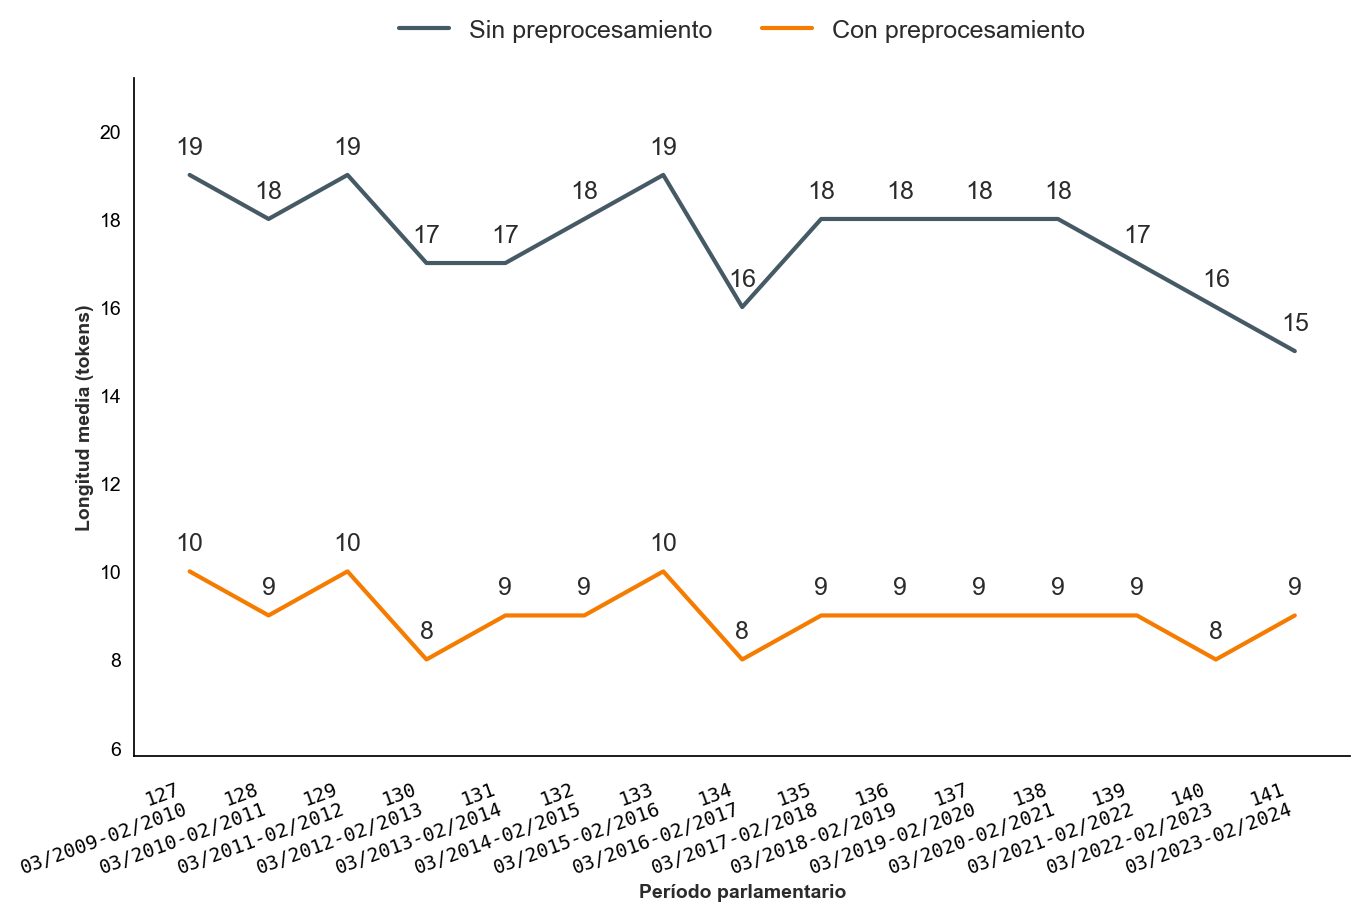

In [18]:
f, ax = plt.subplots(1, 1, figsize=(14, 10))
#ax[0].set_title('Impacto del Preprocesamiento de texto en la Longitud Media de Títulos\n por Período parlamentario', fontweight='bold', fontsize=14, pad=40)


# Subplot 1: Series temporales
ax.plot(periodos, sin_procesamiento, '-', label='Sin preprocesamiento', linewidth=3, color = HEALTH_BLUE)
ax.plot(periodos, con_procesamiento, '-', label='Con preprocesamiento', linewidth=3, color = HEALTH_ORANGE)
ax.set_ylabel('Longitud media (tokens)', fontsize=14, fontweight='bold')
ax.set_xlabel('Período parlamentario', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
xticks = periodos
xtick_labels = [periodos_a_fechas(x) for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, 
                   rotation=20, 
                   ha='right', 
                   fontsize=14,           # Tamaño de fuente más grande
                   family='monospace')    # Fuente monoespaciada para mejor alineación
# Ajustar los márgenes para que las etiquetas no se corten
ax.tick_params(axis='x', which='major', labelsize=14, pad=10)  # Más espacio entre labels y eje
ax.tick_params(axis='y', labelsize=14)


ymin0, ymax0 = ax.get_ylim()
offset0 = (ymax0 - ymin0) * 0.03
# Valores Subplot 1
for x, y in zip(periodos, sin_procesamiento):
    ax.text(x, y + offset0, f'{y:.0f}', ha='center', va='bottom', fontsize=18)

for x, y in zip(periodos, con_procesamiento):
    ax.text(x, y + offset0, f'{y:.0f}', ha='center', va='bottom', fontsize=18)


ax.margins(y=0.20)
# --- AJUSTES FINALES ---

ax.tick_params(axis='both', colors='black')

handles, labels = ax.get_legend_handles_labels()
# Leyenda centrada debajo del título del primer eje
legend  = ax.legend(handles, labels,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.12),  # justo debajo del título
             ncol=2,
             fontsize=18,
             frameon=False)


# Quitar completamente el borde y fondo
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_facecolor("none")



# Ocultar bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mantener solo los ejes izquierdo e inferior en negro
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.grid(False)

# Ajustar layout
plt.tight_layout()
# Dejar espacio arriba para que no choque con el título
plt.subplots_adjust(top=0.85)
#plt.subplots_adjust(bottom=0.2)
plt.savefig(BASE_DIR+"imagenes/evolucion_IL_periodo_tokens_SaludLey.png",
    dpi=300,                      # resolución de imprenta
    bbox_inches="tight",
    pad_inches=0.3)
            
plt.show()


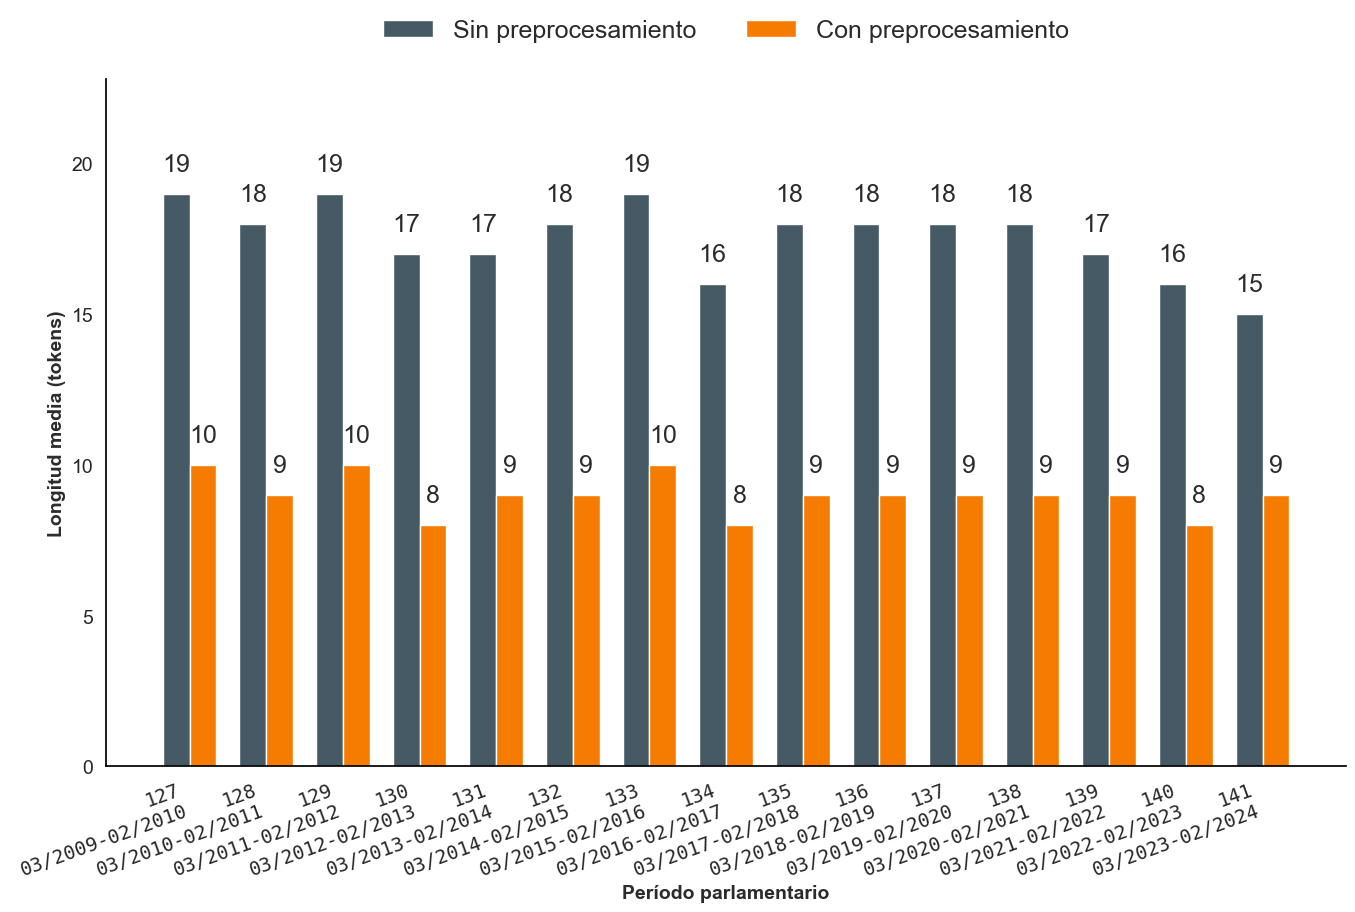

In [19]:
import numpy as np

f, ax = plt.subplots(1, 1, figsize=(14, 10))

# Posiciones base
x = np.arange(len(periodos))
width = 0.35  # ancho de cada barra

# Barras
bars1 = ax.bar(x - width/2, sin_procesamiento, width,
               label='Sin preprocesamiento',
               color=HEALTH_BLUE)

bars2 = ax.bar(x + width/2, con_procesamiento, width,
               label='Con preprocesamiento',
               color=HEALTH_ORANGE)

# Ejes
ax.set_ylabel('Longitud media (tokens)', fontsize=14, fontweight='bold')
ax.set_xlabel('Período parlamentario', fontsize=14, fontweight='bold')

# Ticks eje X
xtick_labels = [periodos_a_fechas(p) for p in periodos]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels,
                   rotation=20,
                   ha='right',
                   fontsize=14,
                   family='monospace')

ax.tick_params(axis='y', labelsize=14)

# --- Etiquetas de valores ---
ymin0, ymax0 = ax.get_ylim()
offset0 = (ymax0 - ymin0) * 0.03

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + offset0,
            f'{h:.0f}', ha='center', va='bottom', fontsize=18)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + offset0,
            f'{h:.0f}', ha='center', va='bottom', fontsize=18)

ax.margins(y=0.20)

# Leyenda
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles, labels,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.12),
                   ncol=2,
                   fontsize=18,
                   frameon=False)

legend.get_frame().set_linewidth(0)

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.grid(False)

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.savefig(BASE_DIR+"imagenes/evolucion_IL_periodo_tokens_SaludLey.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.3)

plt.show()

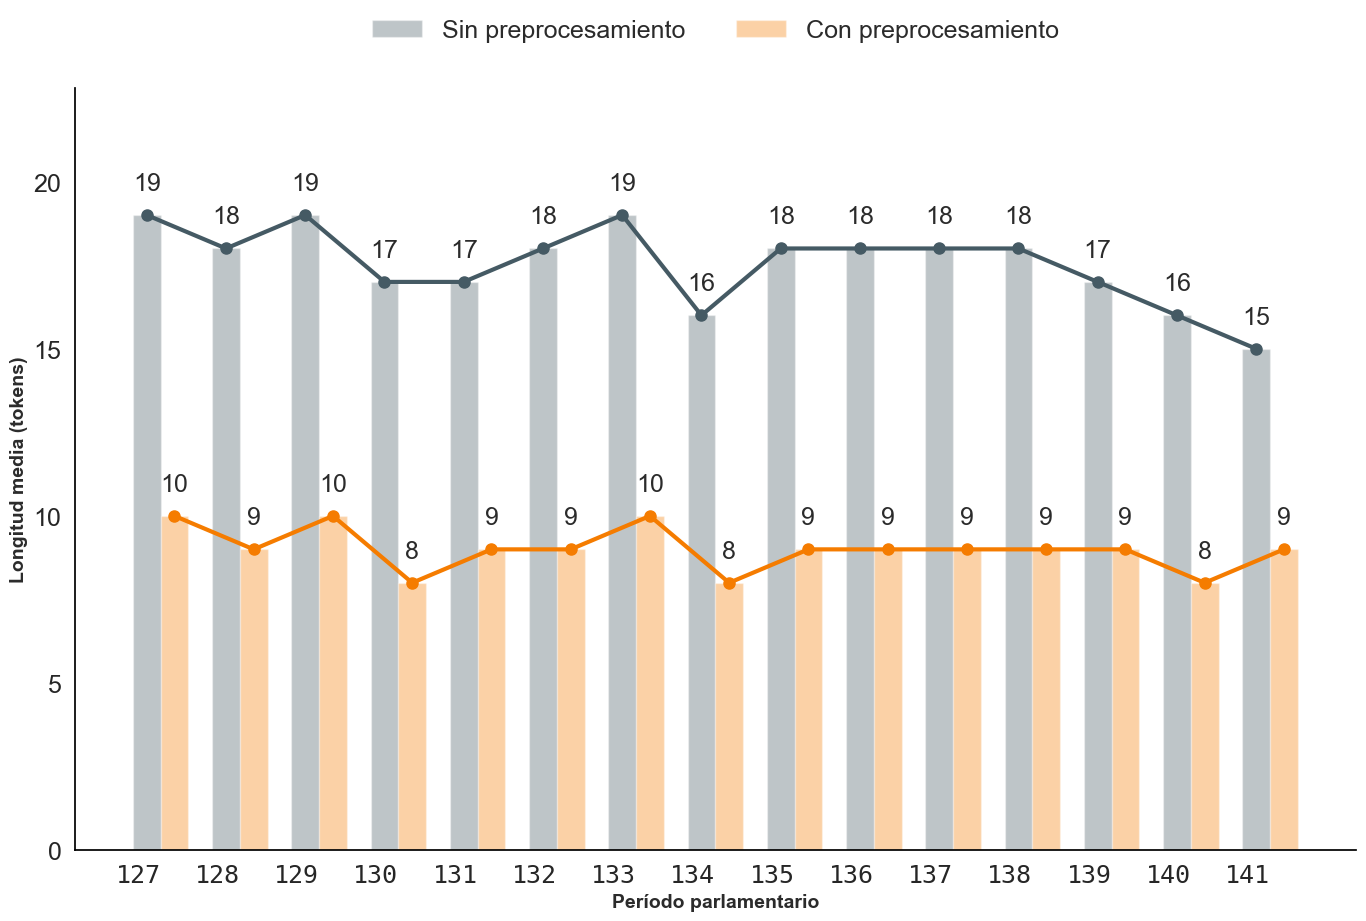

In [21]:
import numpy as np

f, ax = plt.subplots(1, 1, figsize=(14, 10))

# Posiciones base
x = np.arange(len(periodos))
width = 0.35

# Barras (más transparentes)
bars1 = ax.bar(x - width/2, sin_procesamiento, width,
               label='Sin preprocesamiento',
               color=HEALTH_BLUE,
               alpha=0.35)

bars2 = ax.bar(x + width/2, con_procesamiento, width,
               label='Con preprocesamiento',
               color=HEALTH_ORANGE,
               alpha=0.35)

# 🔵 Líneas alineadas con el centro de cada barra
x1 = x - width/2
x2 = x + width/2

ax.plot(x1, sin_procesamiento,
        color=HEALTH_BLUE,
        linewidth=3,
        marker='o',
        markersize=8,
        label='_nolegend_',
        zorder=3)  # arriba de las barras

ax.plot(x2, con_procesamiento,
        color=HEALTH_ORANGE,
        linewidth=3,
        marker='o',
        markersize=8,
        label='_nolegend_',
        zorder=3)

# Ejes
ax.set_ylabel('Longitud media (tokens)', fontsize=14, fontweight='bold')
ax.set_xlabel('Período parlamentario', fontsize=14, fontweight='bold')

# Ticks eje X
#xtick_labels = [periodos_a_fechas(p) for p in periodos]
ax.set_xticks(x)
ax.set_xticklabels( periodos,#xtick_labels,
                   #rotation=20,
                   ha='right',
                   fontsize=18,
                   family='monospace')

ax.tick_params(axis='y', labelsize=18)

# --- Etiquetas de valores ---
ymin0, ymax0 = ax.get_ylim()
offset0 = (ymax0 - ymin0) * 0.03

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + offset0,
            f'{h:.0f}', ha='center', va='bottom', fontsize=18)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + offset0,
            f'{h:.0f}', ha='center', va='bottom', fontsize=18)

ax.margins(y=0.20)

# Leyenda
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles, labels,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.12),
                   ncol=2,
                   fontsize=18,
                   frameon=False)

legend.get_frame().set_linewidth(0)

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.grid(False)

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.savefig(BASE_DIR+"imagenes/evolucion_IL_periodo_tokens_SaludLey.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.3)

plt.show()

In [ ]:
f, ax = plt.subplots(2, 1, figsize=(14, 10), sharex = True)
#ax[0].set_title('Impacto del Preprocesamiento de texto en la Longitud Media de Títulos\n por Período parlamentario', fontweight='bold', fontsize=14, pad=40)


# Subplot 1: Series temporales
ax[0].plot(periodos, sin_procesamiento, '-', label='Sin preprocesamiento', linewidth=3, color = HEALTH_BLUE)
ax[0].plot(periodos, con_procesamiento, '-', label='Con preprocesamiento', linewidth=3, color = HEALTH_ORANGE)
ax[0].set_ylabel('Longitud media (tokens)', fontsize=14, fontweight='bold')
ax[0].tick_params(axis='y', labelsize=14)
# Añadir título descriptivo al eje X

# Subplot 2: % Variación
periodos_variacion = periodos[1:]
ax[1].bar([p - 0.2 for p in periodos_variacion], variacion_sin, 
        width=0.4, label='Sin procesamiento', alpha=0.7,color = HEALTH_BLUE)
ax[1].bar([p + 0.2 for p in periodos_variacion], variacion_con, 
        width=0.4, label='Con procesamiento', alpha=0.7, color = HEALTH_ORANGE)
ax[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax[1].set_xlabel('Período parlamentario', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Variación Interperiodo (%)',fontsize=14, fontweight='bold')
# Configurar los ticks del eje X con las fechas
xticks = periodos
xtick_labels = [periodos_a_fechas(x) for x in xticks]
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xtick_labels, 
                   rotation=20, 
                   ha='right', 
                   fontsize=14,           # Tamaño de fuente más grande
                   family='monospace')    # Fuente monoespaciada para mejor alineación
# Ajustar los márgenes para que las etiquetas no se corten
ax[1].tick_params(axis='x', which='major', labelsize=14, pad=10)  # Más espacio entre labels y eje
ax[1].tick_params(axis='y', labelsize=14)


ymin0, ymax0 = ax[0].get_ylim()
offset0 = (ymax0 - ymin0) * 0.03
# Valores Subplot 1
for x, y in zip(periodos, sin_procesamiento):
    ax[0].text(x, y + offset0, f'{y:.0f}', ha='center', va='bottom', fontsize=18)

for x, y in zip(periodos, con_procesamiento):
    ax[0].text(x, y + offset0, f'{y:.0f}', ha='center', va='bottom', fontsize=18)


# Calcular un desplazamiento proporcional al rango del eje Y
ymin, ymax = ax[1].get_ylim()
offset = (ymax - ymin) * 0.04   # 4% del alto del gráfico
# Valores Subplot 2
for x, y in zip([p - 0.4 for p in periodos_variacion], variacion_sin):
    print(x,y)

    if (y!=0):
        ax[1].text(x, y + offset if y >= 0 else y - offset,f"{locale.format_string('%.2f', y)}", ha='center',
               va='bottom' if y >= 0 else 'top', fontsize=18)
    else:
        ax[1].text(x, y, '0',ha='center', fontsize=18)
        

for x, y in zip([p + 0.4 for p in periodos_variacion], variacion_con):
  
    if (y!=0):
        ax[1].text(x, y + offset if y >= 0 else y - offset, f"{locale.format_string('%.2f', y)}", ha='center',
               va='bottom' if y >= 0 else 'top', fontsize=18)
    else:
        ax[1].text(x, y, '0',ha='center', fontsize=18)
        

for a in ax:
    a.margins(y=0.20)
# --- AJUSTES FINALES ---

ax[0].tick_params(axis='both', colors='black')
ax[1].tick_params(axis='both', colors='black')

handles, labels = ax[0].get_legend_handles_labels()
# Leyenda centrada debajo del título del primer eje
legend  = ax[0].legend(handles, labels,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.12),  # justo debajo del título
             ncol=2,
             fontsize=18,
             frameon=False)


# Quitar completamente el borde y fondo
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_facecolor("none")

ax[0].grid(False)

# Ocultar bordes superior y derecho
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# Mantener solo los ejes izquierdo e inferior en negro
ax[0].spines['left'].set_color('black')
ax[0].spines['bottom'].set_color('black')

ax[1].grid(False)

# Ocultar bordes superior y derecho
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# Mantener solo los ejes izquierdo e inferior en negro
ax[1].spines['left'].set_color('black')
ax[1].spines['bottom'].set_color('black')


# Ajustar layout
plt.tight_layout()
# Dejar espacio arriba para que no choque con el título
plt.subplots_adjust(top=0.85)
#plt.subplots_adjust(bottom=0.2)
#plt.savefig(BASE_DIR+"imagenes/evolucion_IL_periodo_tokens_SaludLey.png",
#    dpi=300,                      # resolución de imprenta
#    bbox_inches="tight",
#    pad_inches=0.3)
            
plt.show()


####  Figura 4.4